<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-04-15 09:49:54--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite.2’

survey-results-publ 100%[===================>] 201.62M  47.5MB/s    in 4.3s    

2026-04-15 09:50:01 (46.4 MB/s) - ‘survey-results-public.sqlite.2’ saved [211415040/211415040]



#### 2. Connect to the Database


**Install the needed libraries**


In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 110.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 129.5 MB/s eta 0:00:00


In [3]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 106.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 120.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 110.2 MB/s eta 0:00:00


In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [5]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


#### Demo 2: List All Tables


In [6]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [7]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


Note: you may need to restart the kernel to use updated packages.


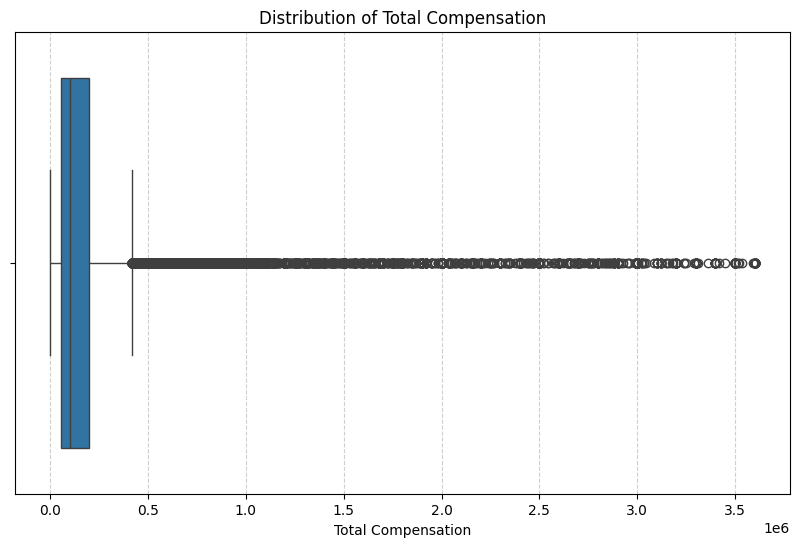

In [8]:
%pip install seaborn
import seaborn as sns

query = "SELECT CompTotal FROM main"
df_comp = pd.read_sql_query(query, conn)

# Convert to numeric and remove missing values
df_comp['CompTotal'] = pd.to_numeric(df_comp['CompTotal'], errors='coerce')
df_comp = df_comp.dropna(subset=['CompTotal'])

# Handle outliers for a clearer visualization
# Visualize data up to the 95th percentile to see the main distribution clearly.
upper_limit = df_comp['CompTotal'].quantile(0.95)
df_filtered = df_comp[df_comp['CompTotal'] <= upper_limit]

# Create the Box Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_filtered['CompTotal'])

# Add titles and labels
plt.title('Distribution of Total Compensation')
plt.xlabel('Total Compensation')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


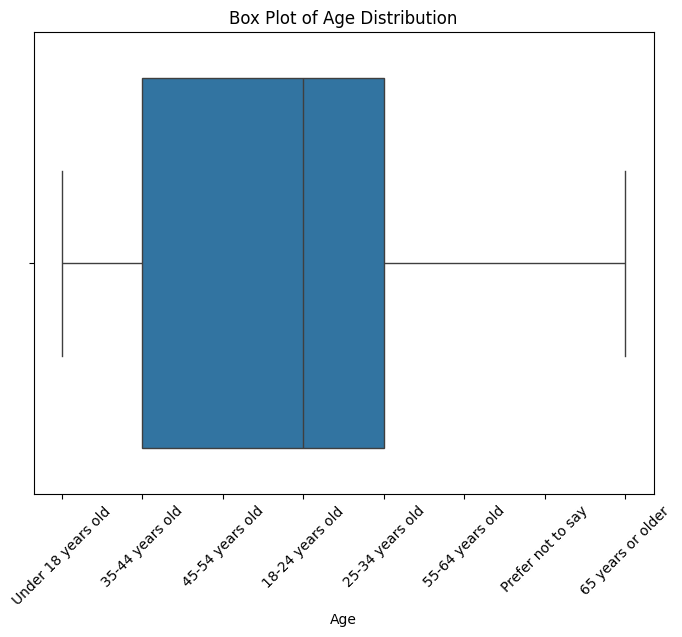

In [9]:
QUERY2 = """
SELECT Age
FROM main
"""

# 2. Load the data into a DataFrame
df_age = pd.read_sql_query(QUERY2, conn)

# 3. Create the box plot
plt.figure(figsize=(8, 6))
sns.boxplot(x=df_age['Age'])

# 4. Add titles and labels
plt.title('Box Plot of Age Distribution')
plt.xlabel('Age')
plt.xticks(rotation=45)

# Display the plot
plt.show()

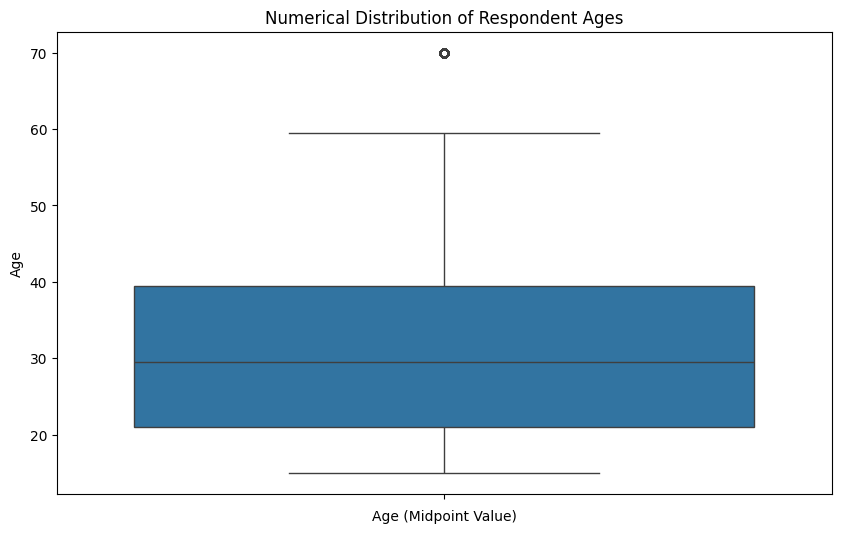

In [11]:
# your code goes here
query = "SELECT Age FROM main"
df = pd.read_sql_query(query,conn)
age_mapping = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70
}

#  Apply the mapping to create a new numerical column
df['Age_Numerical'] = df['Age'].map(age_mapping)

# Drop rows where age couldn't be converted (e.g., 'Prefer not to say')
df_plot = df.dropna(subset=['Age_Numerical'])

# Visualize the distribution with a histogram
plt.figure(figsize=(10, 6))
sns.boxplot(df_plot['Age_Numerical'])

plt.title('Numerical Distribution of Respondent Ages')
plt.ylabel('Age')
plt.xlabel('Age (Midpoint Value)')


plt.show()

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


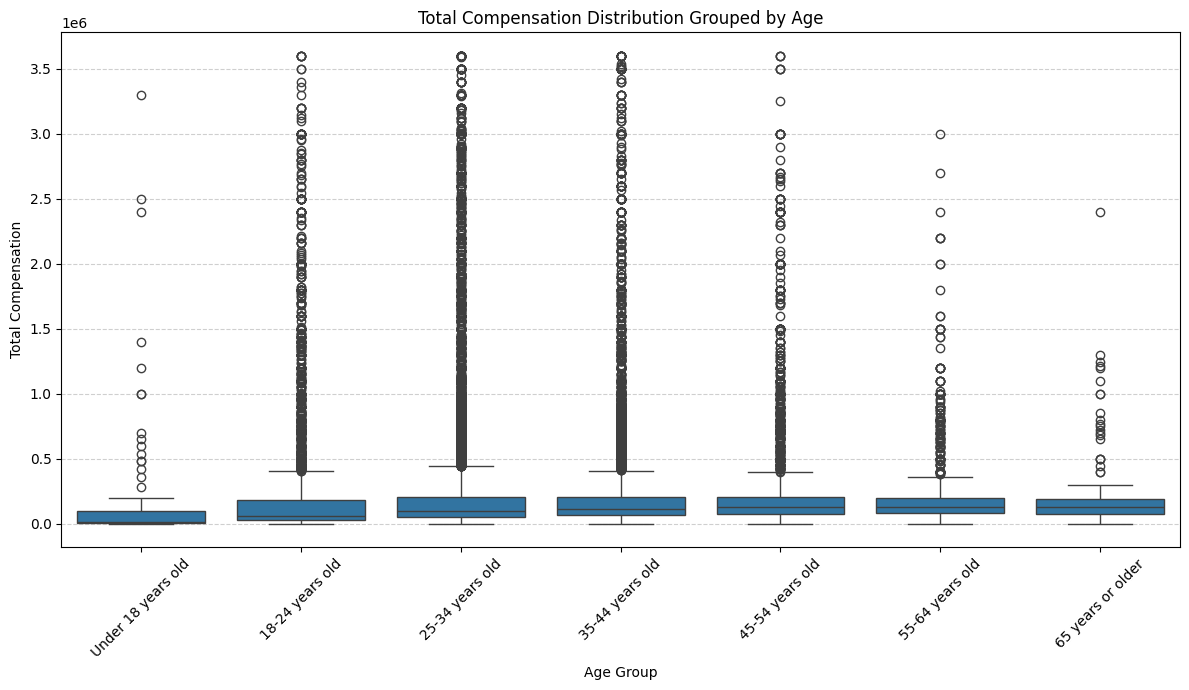

In [10]:
# your code goes here
query = "SELECT CompTotal, Age FROM main"
df = pd.read_sql_query(query,conn)

# Convert to numeric and remove missing values
df['CompTotal'] = pd.to_numeric(df['CompTotal'], errors='coerce')
df_clean = df.dropna(subset=['CompTotal', 'Age'])

# Handle extreme outliers for clarity (filtering to the 95th percentile)
upper_limit = df_clean['CompTotal'].quantile(0.95)
df_filtered = df_clean[df_clean['CompTotal'] <= upper_limit]

# Define the logical chronological order for Age groups
age_order = [
    'Under 18 years old',
    '18-24 years old',
    '25-34 years old',
    '35-44 years old',
    '45-54 years old',
    '55-64 years old',
    '65 years or older'
]

# Create the Grouped Box Plot
plt.figure(figsize=(12, 7))
sns.boxplot(x='Age', y='CompTotal', data=df_filtered, order=age_order)

# 6. Formatting
plt.title('Total Compensation Distribution Grouped by Age')
plt.xlabel('Age Group')
plt.ylabel('Total Compensation')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


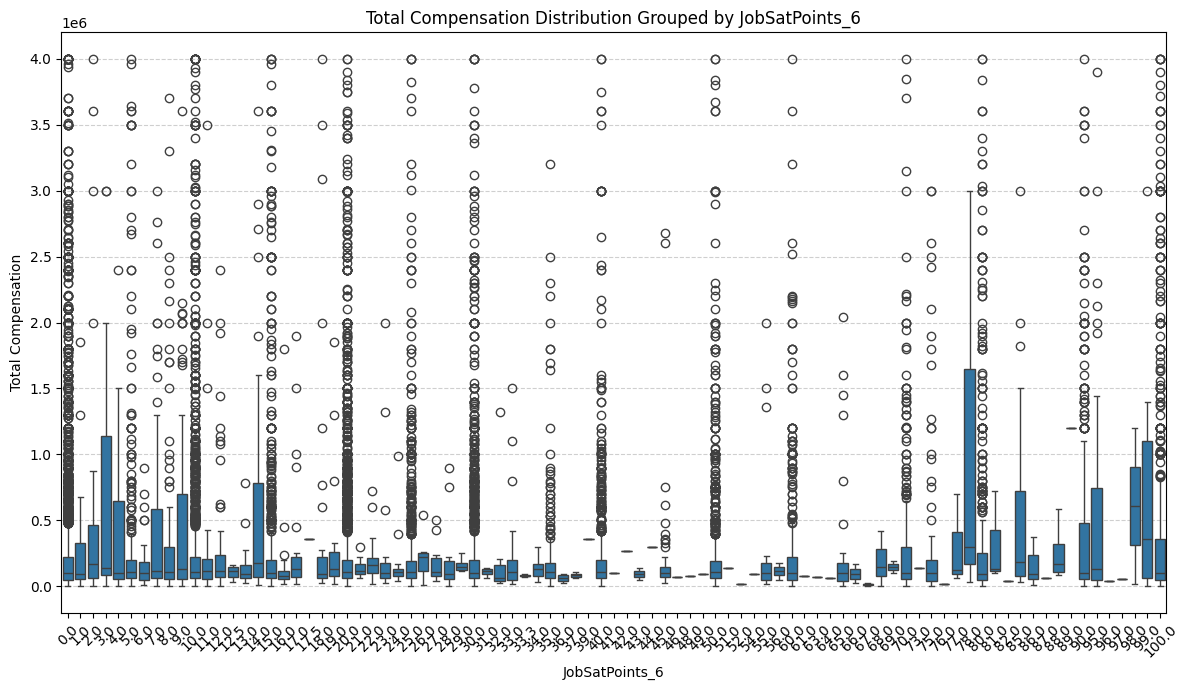

In [11]:
# your code goes here

query = "SELECT CompTotal, JobSatPoints_6 FROM main"
df = pd.read_sql_query(query,conn)

# Convert to numeric and remove missing values
df['CompTotal'] = pd.to_numeric(df['CompTotal'], errors='coerce')
df_clean = df.dropna(subset=['CompTotal', 'JobSatPoints_6'])

# Handle extreme outliers for clarity (filtering to the 95th percentile)
upper_limit = df_clean['CompTotal'].quantile(0.95)
df_filtered = df_clean[df_clean['CompTotal'] <= upper_limit]

# Create the Grouped Box Plot
plt.figure(figsize=(12, 7))
sns.boxplot(x='JobSatPoints_6', y='CompTotal', data=df_filtered)

# 6. Formatting
plt.title('Total Compensation Distribution Grouped by JobSatPoints_6')
plt.xlabel('JobSatPoints_6')
plt.ylabel('Total Compensation')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


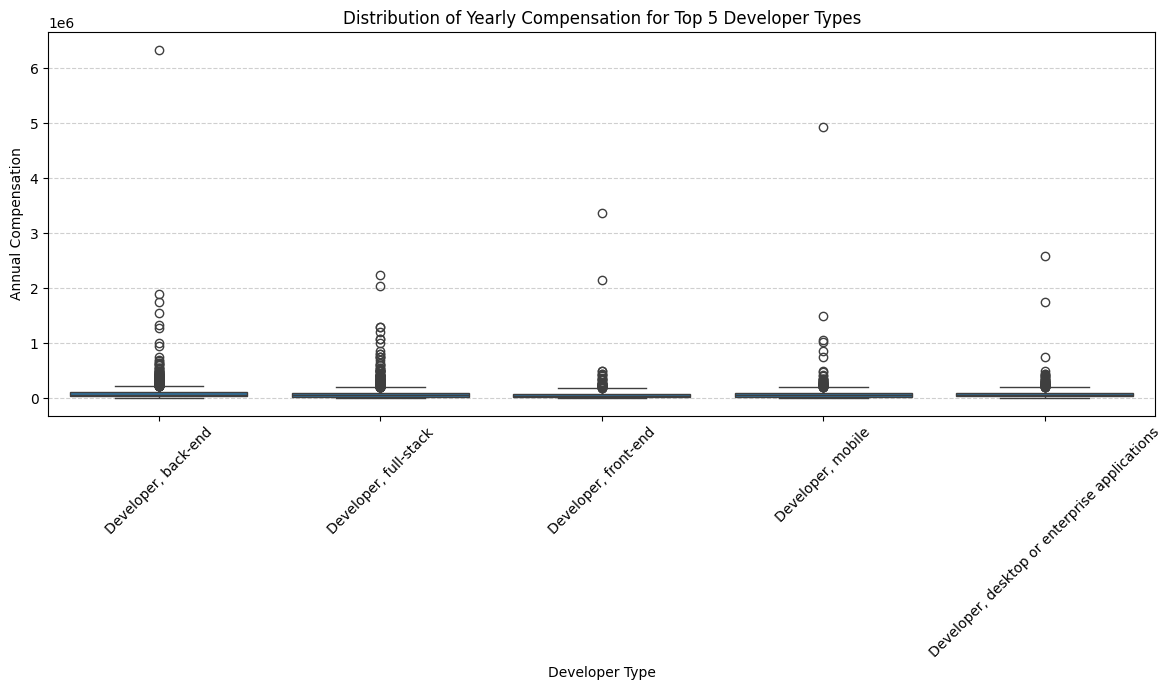

In [12]:
query = "SELECT DevType, ConvertedCompYearly FROM main"
df = pd.read_sql_query(query, conn)

#Explode the DevType if it contains multiple roles

df = df.dropna(subset=['DevType', 'ConvertedCompYearly'])
df_exploded = df.assign(DevType=df['DevType'].str.split(';')).explode('DevType')

# Identify the Top 5 Developer Types
top_5_types = df_exploded['DevType'].value_counts().nlargest(5).index

# Filter data to include only Top 5
df_top_5 = df_exploded[df_exploded['DevType'].isin(top_5_types)]

# Create the Box Plot
plt.figure(figsize=(12, 7))
sns.boxplot(x='DevType', y='ConvertedCompYearly', data=df_top_5)

# Formatting
plt.title('Distribution of Yearly Compensation for Top 5 Developer Types')
plt.xlabel('Developer Type')
plt.ylabel('Annual Compensation')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


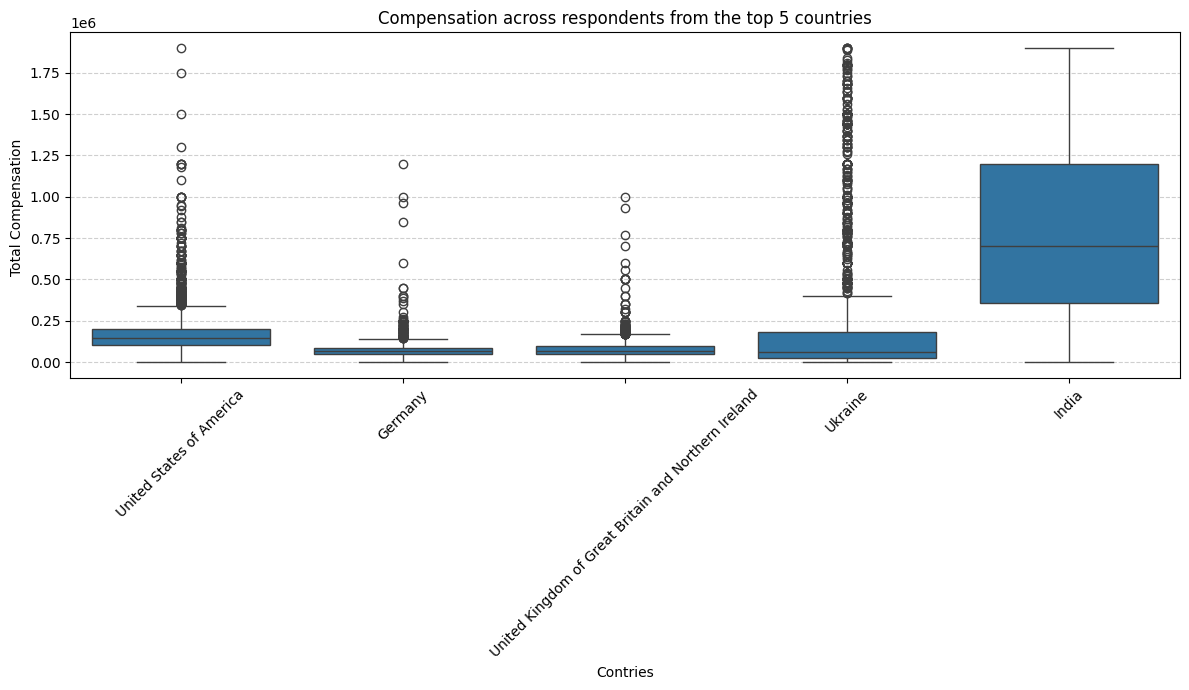

In [14]:
# your code goes here
query = "SELECT CompTotal, Country FROM main"
df = pd.read_sql_query(query, conn)

# Convert to numeric and remove missing values
df['CompTotal'] = pd.to_numeric(df['CompTotal'], errors='coerce')
df = df.dropna(subset=['CompTotal', 'Country'])

# Identify the Top 5 Countries
top_5_countries = df['Country'].value_counts().nlargest(5).index

# Filter data to include only Top 5
df_top_5 = df[df['Country'].isin(top_5_countries)]

upper_limit = df_top_5['CompTotal'].quantile(0.95)
df_filtered = df_top_5[df_top_5['CompTotal'] <= upper_limit]

# Create the Box Plot
plt.figure(figsize=(12, 7))
sns.boxplot(x='Country', y='CompTotal', data=df_filtered, order=top_5_countries)

# Formatting
plt.title('Compensation across respondents from the top 5 countries')
plt.xlabel('Contries')
plt.ylabel('Total Compensation ')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


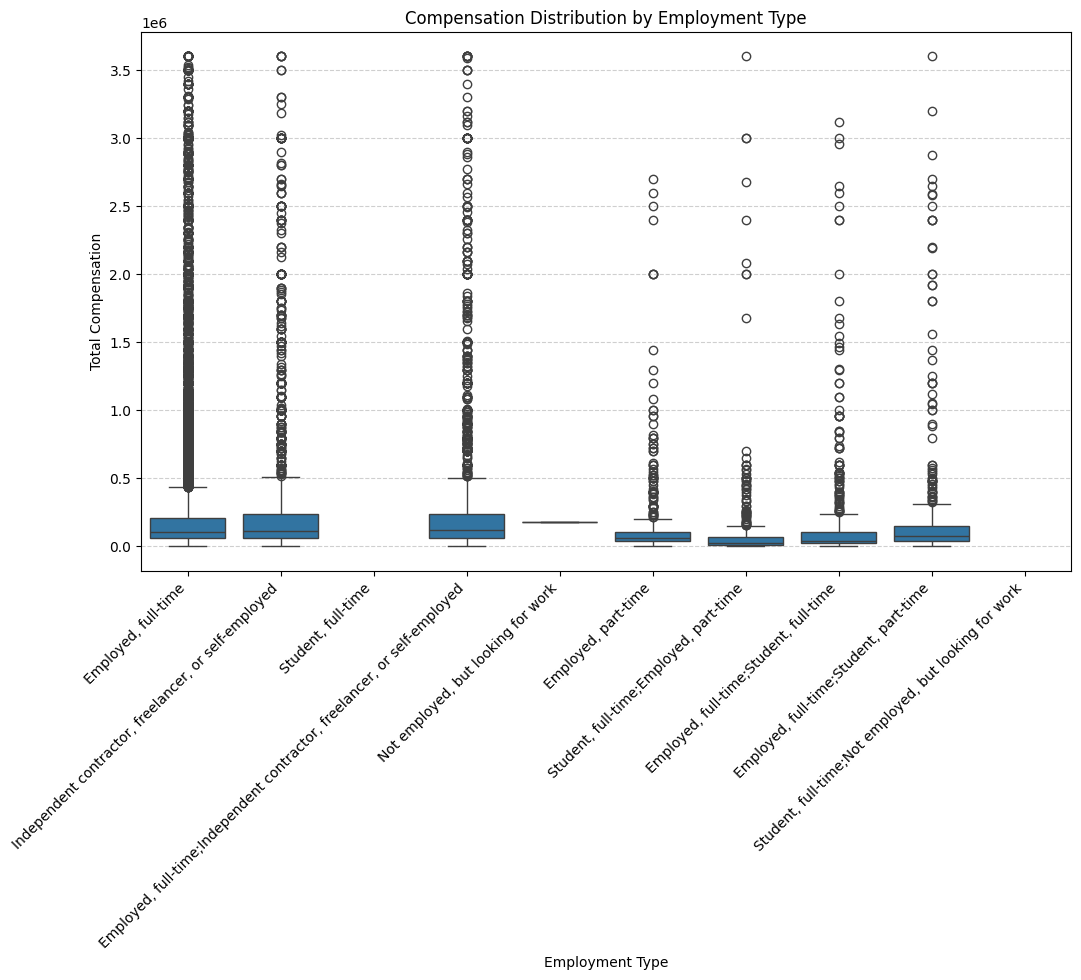

In [18]:
# your code goes here

query = "SELECT Employment, CompTotal FROM main"
df = pd.read_sql_query(query, conn)

# Remove rows with no employment info or no compensation
df_clean = df.dropna(subset=['Employment', 'CompTotal'])

top_10emp = df['Employment'].value_counts().nlargest(10).index

# Filter data to include only Top 5
df_top_10 = df[df['Employment'].isin(top_10emp)]

# Filtering outliers (using 95th percentile to keep the plot readable)
upper_limit = df_clean['CompTotal'].quantile(0.95)
df_filtered = df_clean[df_clean['CompTotal'] <= upper_limit]

# Create the Box Plot
plt.figure(figsize=(12, 7))
sns.boxplot(x='Employment', y='CompTotal', data=df_filtered, order=top_10emp)

# Formatting
plt.title('Compensation Distribution by Employment Type')
plt.xlabel('Employment Type')
plt.ylabel('Total Compensation')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


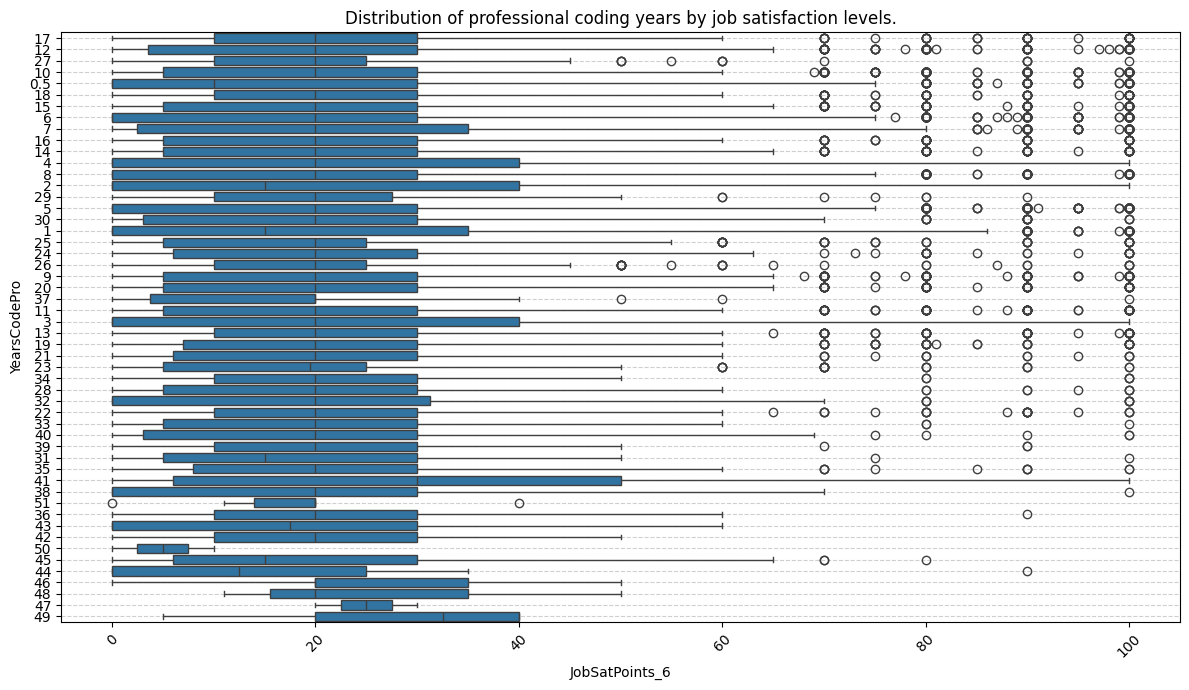

In [20]:
# your code goes here

query = "SELECT YearsCodePro, JobSatPoints_6 FROM main"
df = pd.read_sql_query(query,conn)

df['YearsCodePro'] = df['YearsCodePro'].replace({
    'Less than 1 year': 0.5, 
    'More than 50 years': 51
})

# Remove missing values
df_clean = df.dropna(subset=['YearsCodePro', 'JobSatPoints_6'])

# Create the Grouped Box Plot
plt.figure(figsize=(12, 7))
sns.boxplot(x='JobSatPoints_6', y='YearsCodePro', data=df_clean)

# Formatting
plt.title('Distribution of professional coding years by job satisfaction levels.')
plt.xlabel('JobSatPoints_6')
plt.ylabel('YearsCodePro')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [21]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
